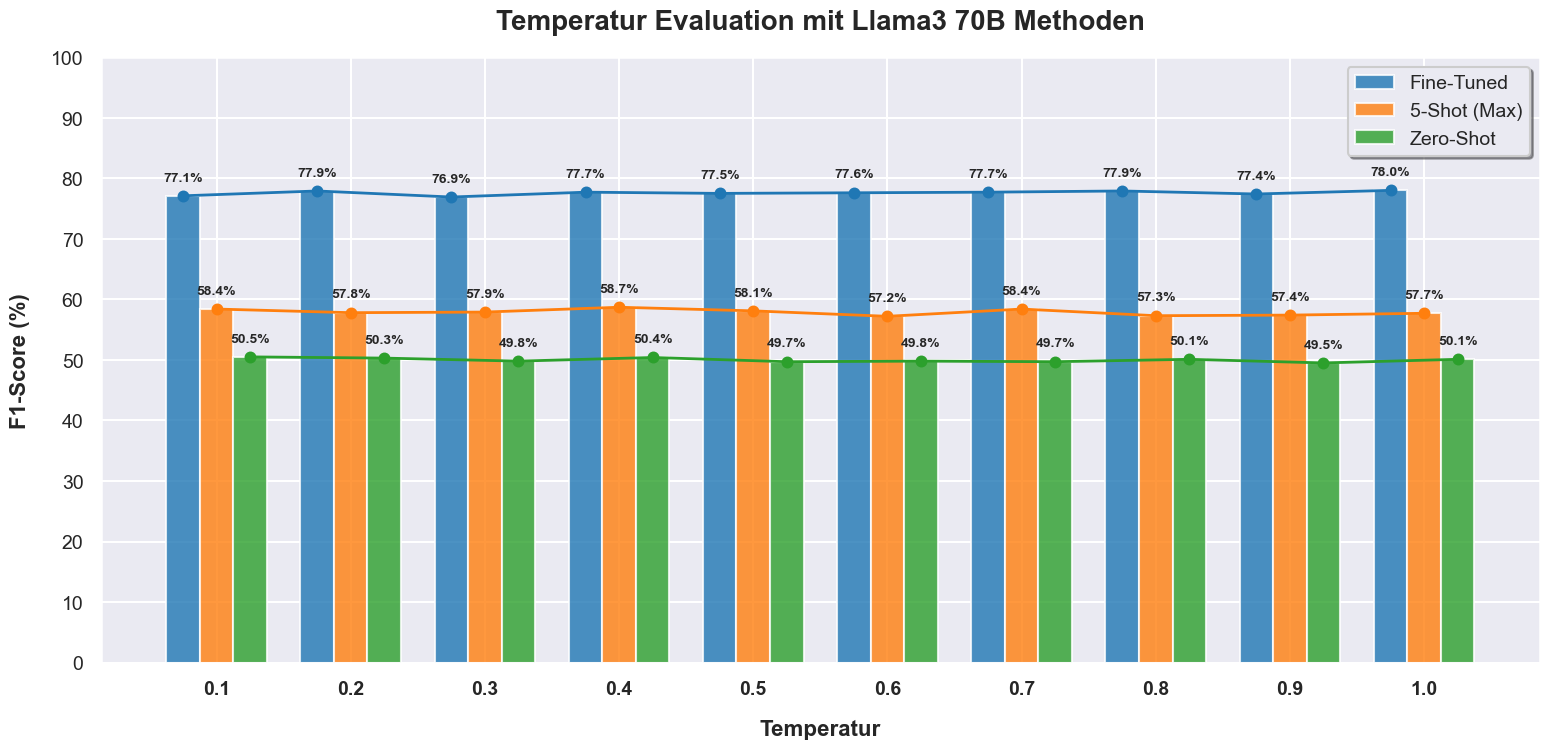

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Funktion zum Plotten der F1-Scores bei verschiedenen Temperaturen
def plot_f1_scores_temperature(f1_scores):

    temperatures = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    f1_scores_fine_tuned = f1_scores['Fine-Tuned']
    f1_scores_5shot = f1_scores['5-Shot (Max)']
    f1_scores_0shot = f1_scores['Zero-Shot']

    x = np.arange(len(temperatures))
    bar_width = 0.25

    plt.figure(figsize=(16, 8))
    sns.set(style="darkgrid")
    sns.set_context("talk", font_scale=1.3)

    # Bars
    plt.bar(x - bar_width, f1_scores_fine_tuned, bar_width, alpha=0.8, color='#1f77b4', label='Fine-Tuned')
    plt.bar(x, f1_scores_5shot, bar_width, alpha=0.8, color='#ff7f0e', label='5-Shot (Max)')
    plt.bar(x + bar_width, f1_scores_0shot, bar_width, alpha=0.8, color='#2ca02c', label='Zero-Shot')

    # Lines
    plt.plot(x - bar_width, f1_scores_fine_tuned, color='#1f77b4', linestyle='-', linewidth=2)
    plt.plot(x, f1_scores_5shot, color='#ff7f0e', linestyle='-', linewidth=2)
    plt.plot(x + bar_width, f1_scores_0shot, color='#2ca02c', linestyle='-', linewidth=2)

    # Punkte in der Mitte der Balken
    plt.scatter(x - bar_width, f1_scores_fine_tuned, color='#1f77b4', s=50, zorder=3)
    plt.scatter(x, f1_scores_5shot, color='#ff7f0e', s=50, zorder=3)
    plt.scatter(x + bar_width, f1_scores_0shot, color='#2ca02c', s=50, zorder=3)

    # Achsen und Titel
    plt.xlabel('Temperatur', fontsize=16, fontweight='bold', labelpad=15)
    plt.ylabel('F1-Score (%)', fontsize=16, fontweight='bold', labelpad=15)
    plt.title('Temperatur Evaluation mit Llama3 70B Methoden', fontsize=20, fontweight='bold', pad=20)

    # Achsenanpassungen
    plt.xticks(x, temperatures, fontsize=14, fontweight='bold')
    plt.yticks(np.arange(0, 101, 10), fontsize=14)
    plt.ylim(0, 100)

    # Legende
    plt.legend(fontsize=14, loc='upper right', frameon=True, fancybox=True, shadow=True)

    # Werte auf den Balken mit Prozentangabe
    for i, v in enumerate(f1_scores_fine_tuned):
        plt.text(i - bar_width, v + 2, f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    for i, v in enumerate(f1_scores_5shot):
        plt.text(i, v + 2, f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    for i, v in enumerate(f1_scores_0shot):
        plt.text(i + bar_width, v + 2, f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Plot speichern und anzeigen
    plt.tight_layout()
    plt.savefig('pics/temperatur.svg', format='svg', bbox_inches='tight')
    plt.show()

# F1-Scores aus der LaTeX-Tabelle
f1_scores = {
    'Fine-Tuned': [77.1, 77.9, 76.9, 77.7, 77.5, 77.6, 77.7, 77.9, 77.4, 78.0],
    'Zero-Shot': [50.5, 50.3, 49.8, 50.4, 49.7, 49.8, 49.7, 50.1, 49.5, 50.1],
    '5-Shot (Max)': [58.4, 57.8, 57.9, 58.7, 58.1, 57.2, 58.4, 57.3, 57.4, 57.7]
}

plot_f1_scores_temperature(f1_scores)